In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

plt.rc('figure', autolayout=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)



TensorFlow version: 2.21.0
NumPy version: 2.2.6


# Introduction
Generative AI learns patterns from existing data and produces new samples.
In this notebook, we will train a convolutional autoencoder on MNIST digits.
After training, we will reconstruct digits and sample the latent space to generate new ones.



In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)



Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


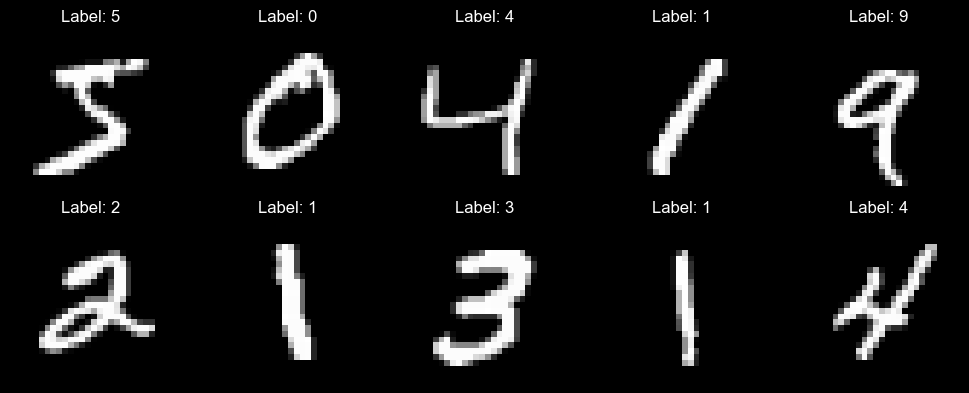

In [3]:
# Visualize sample digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
	ax.imshow(x_train[i], cmap='gray')
	ax.set_title(f"Label: {y_train[i]}")
	ax.axis('off')

plt.show()



In [4]:
# Normalize and reshape images for convolutional layers
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Normalized training shape:", x_train.shape)
print("Normalized test shape:", x_test.shape)
print("Pixel range:", float(x_train.min()), "to", float(x_train.max()))



Normalized training shape: (60000, 28, 28, 1)
Normalized test shape: (10000, 28, 28, 1)
Pixel range: 0.0 to 1.0


In [5]:
# Define latent space size
latent_dim = 2
print("Latent space dimension:", latent_dim)



Latent space dimension: 2


In [6]:
# Build encoder
encoder_inputs = tf.keras.Input(shape=(28, 28, 1), name="encoder_input")

x = tf.keras.layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(encoder_inputs)
x = tf.keras.layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
latent = tf.keras.layers.Dense(latent_dim, name="latent_space")(x)

encoder = tf.keras.Model(encoder_inputs, latent, name="encoder")
encoder.summary()



Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,714 (858.26 KB)

 Trainable params: 219,714 (858.26 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Build decoder
decoder_inputs = tf.keras.Input(shape=(latent_dim,), name="decoder_input")

x = tf.keras.layers.Dense(7 * 7 * 64, activation='relu')(decoder_inputs)
x = tf.keras.layers.Reshape((7, 7, 64))(x)
x = tf.keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
x = tf.keras.layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
decoder_outputs = tf.keras.layers.Conv2DTranspose(1, 3, padding='same', activation='sigmoid')(x)

decoder = tf.keras.Model(decoder_inputs, decoder_outputs, name="decoder")
decoder.summary()



Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Combine encoder and decoder into an autoencoder
autoencoder_inputs = tf.keras.Input(shape=(28, 28, 1), name="autoencoder_input")
encoded_images = encoder(autoencoder_inputs)
reconstructed_images = decoder(encoded_images)

autoencoder = tf.keras.Model(autoencoder_inputs, reconstructed_images, name="autoencoder")
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()



Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 2)              │       219,714 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │        65,089 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 284,803 (1.09 MB)

 Trainable params: 284,803 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train the autoencoder
epochs = 15
batch_size = 128

history = autoencoder.fit(
	x_train,
	x_train,
	epochs=epochs,
	batch_size=batch_size,
	validation_data=(x_test, x_test)
)



Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.2588 - val_loss: 0.2134
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.2087 - val_loss: 0.2023
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.1972 - val_loss: 0.1932
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.1900 - val_loss: 0.1881
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1860 - val_loss: 0.1849
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1836 - val_loss: 0.1830
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1817 - val_loss: 0.1818
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1803 - val_loss: 0.1806
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1792 - val_loss: 0.1796
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1781 - val_loss: 0.1787
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.1772 - val_loss: 0.1781
Epoch 12/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 

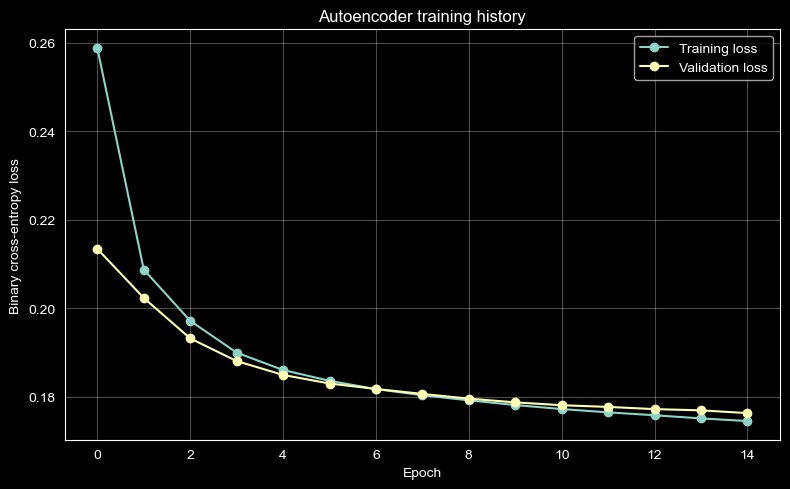

In [10]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], marker='o', label='Training loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation loss')
plt.title("Autoencoder training history")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



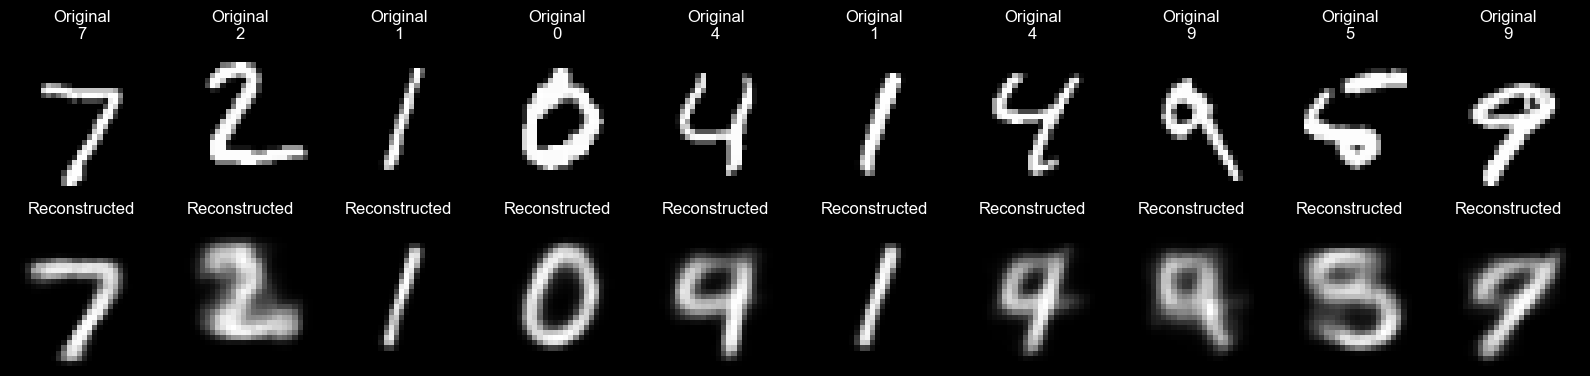

In [11]:
# Reconstruct sample test digits
num_examples = 10
sample_images = x_test[:num_examples]
sample_labels = y_test[:num_examples]
reconstructed = autoencoder.predict(sample_images, verbose=0)

fig, axes = plt.subplots(2, num_examples, figsize=(16, 4))

for i in range(num_examples):
	axes[0, i].imshow(sample_images[i].squeeze(), cmap='gray')
	axes[0, i].set_title(f"Original\n{sample_labels[i]}")
	axes[0, i].axis('off')

	axes[1, i].imshow(reconstructed[i].squeeze(), cmap='gray')
	axes[1, i].set_title("Reconstructed")
	axes[1, i].axis('off')

plt.show()



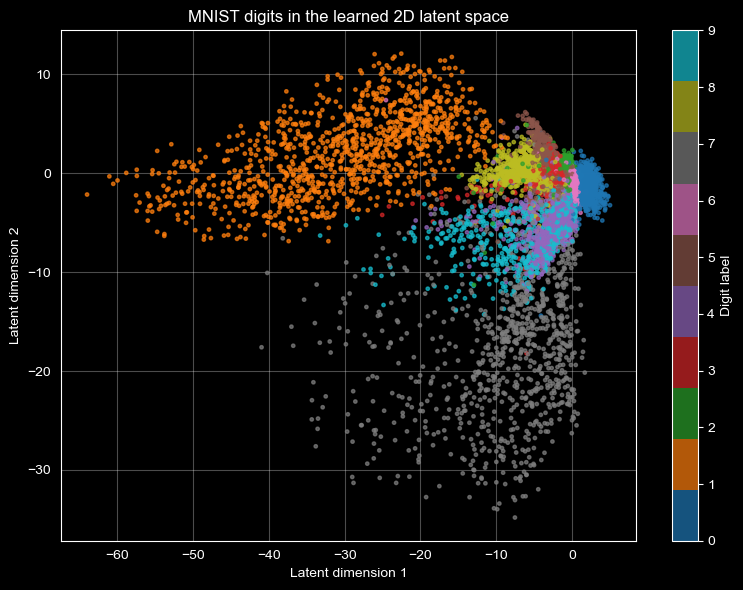

In [12]:
# Encode the test set and visualize the 2D latent space
latent_vectors = encoder.predict(x_test, verbose=0)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
	latent_vectors[:, 0],
	latent_vectors[:, 1],
	c=y_test,
	cmap='tab10',
	s=6,
	alpha=0.7
)
plt.colorbar(scatter, label="Digit label")
plt.title("MNIST digits in the learned 2D latent space")
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.grid(alpha=0.3)
plt.show()



Grid X values: [-4.         -3.11111111 -2.22222222 -1.33333333 -0.44444444  0.44444444
  1.33333333  2.22222222  3.11111111  4.        ]
Grid Y values: [-4.         -3.11111111 -2.22222222 -1.33333333 -0.44444444  0.44444444
  1.33333333  2.22222222  3.11111111  4.        ]


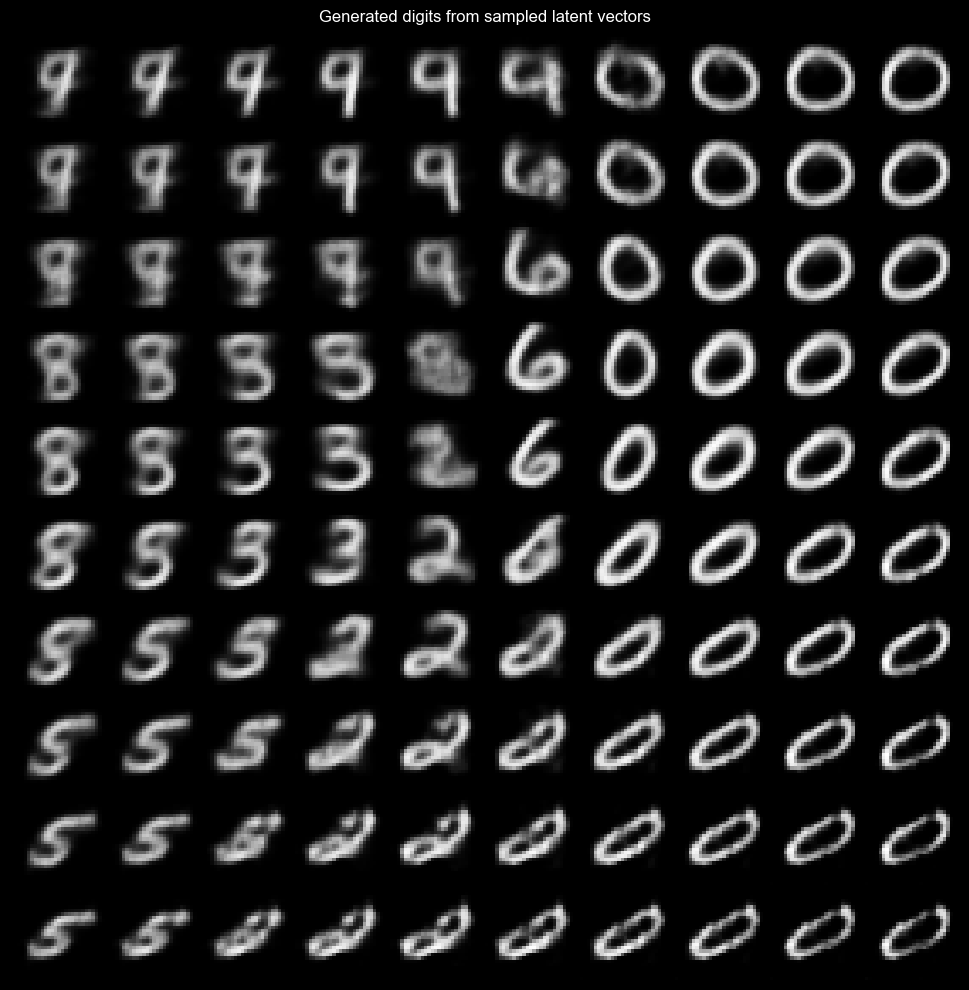

In [13]:
#Generate new images by sampling a grid of latent vectors
grid_size = 10
digit_size = 28
generated_canvas = np.zeros((digit_size * grid_size, digit_size * grid_size))

grid_x = np.linspace(-4, 4, grid_size)
grid_y = np.linspace(-4, 4, grid_size)
print("Grid X values:", grid_x)
print("Grid Y values:", grid_y)

for row_index, y_value in enumerate(grid_y):
	for col_index, x_value in enumerate(grid_x):
		latent_sample = np.array([[x_value, y_value]], dtype=np.float32)
		decoded_digit = decoder.predict(latent_sample, verbose=0)[0].squeeze()

		row_start = row_index * digit_size
		row_end = (row_index + 1) * digit_size
		col_start = col_index * digit_size
		col_end = (col_index + 1) * digit_size

		generated_canvas[row_start:row_end, col_start:col_end] = decoded_digit

plt.figure(figsize=(10, 10))
plt.imshow(generated_canvas, cmap='gray')
plt.title("Generated digits from sampled latent vectors")
plt.axis('off')
plt.show()



# Summary

The encoder compresses an image into a compact latent representation.
The decoder reconstructs an image from that latent representation.
Sampling the latent space allows us to generate new digit-like images.
Autoencoders are a simple starting point for understanding generative AI.
More advanced generative models include VAEs, GANs, and diffusion models.
